<a href="https://colab.research.google.com/github/sakshammverma/finetuing_llm/blob/main/instruct_pretrain_ft.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Download a pretrained BASEMODEL(LLAMA) \
Non instruction fine tuning on plain text() \
Instruction fine tuning on a instruction dataset \
Alignment preference

In [ ]:
!pip install -U transformers peft bitsandbytes datasets accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 114.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 14.0 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
!pip install -U trl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 531.0/531.0 kB 37.2 MB/s eta 0:00:00


In [ ]:
raw_document = """An Advanced Persistent Threat (APT) is a stealthy threat actor, typically a nation-state or state-sponsored group, which gains unauthorized access to a computer network and remains undetected for an extended period. Unlike automated malware, APTs are carefully orchestrated by human operators who actively adapt to the target's defenses.

The lifecycle of an APT attack typically involves several distinct phases: initial compromise, escalation of privileges, internal reconnaissance, lateral movement, and data exfiltration. Attackers often use spear-phishing emails or exploit zero-day vulnerabilities to establish their initial foothold before moving deeper into the network.

To defend against APTs, organizations must adopt a robust defense-in-depth strategy. This requires moving away from perimeter-only security and implementing a Zero Trust Architecture. Continuous network monitoring, anomaly detection, and endpoint detection and response (EDR) systems are critical for identifying the subtle footprints left by these actors."""

In [ ]:
import json

def chunk_by_paragraph(text_document):
    paragraphs = text_document.strip().split('\n\n')
    training_dataset = []

    for para in paragraphs:
        clean_para = para.replace('\n', ' ').strip()
        formatted_line = {
            "text": f"{clean_para} </s>"
        }
        training_dataset.append(formatted_line)

    return training_dataset

chunked_data = chunk_by_paragraph(raw_document)

with open("apt_domain_training.jsonl", "w") as f:
    for item in chunked_data:
        f.write(json.dumps(item) + "\n")
        print(json.dumps(item))

{"text": "An Advanced Persistent Threat (APT) is a stealthy threat actor, typically a nation-state or state-sponsored group, which gains unauthorized access to a computer network and remains undetected for an extended period. Unlike automated malware, APTs are carefully orchestrated by human operators who actively adapt to the target's defenses. </s>"}
{"text": "The lifecycle of an APT attack typically involves several distinct phases: initial compromise, escalation of privileges, internal reconnaissance, lateral movement, and data exfiltration. Attackers often use spear-phishing emails or exploit zero-day vulnerabilities to establish their initial foothold before moving deeper into the network. </s>"}
{"text": "To defend against APTs, organizations must adopt a robust defense-in-depth strategy. This requires moving away from perimeter-only security and implementing a Zero Trust Architecture. Continuous network monitoring, anomaly detection, and endpoint detection and response (EDR) sy

In [ ]:
from datasets import Dataset, load_dataset
dataset = Dataset.from_list(chunked_data)

In [ ]:
dataset

Dataset({
    features: ['text'],
    num_rows: 3
})

Here we are not specifying something means we are doing full fine tuning
# We got 2 methods for Partial finetuning


*   Freeze some layer and fine tune the unfreezed layer like we do in cnn(not appropriate method there are some pros and cons, not efficient  to larger llm's)
*   LORA(append some external weight to pretrained)



# IMPLEMENT LORA

In [ ]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()

In [ ]:

from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, Trainer
from peft import LoraConfig, get_peft_model, TaskType
from datasets import load_dataset

In [ ]:
model = "TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T"


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(model)

config.json:   0%|          | 0.00/560 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/776 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

In [ ]:
if tokenizer.pad_token is None:
  tokenizer.pad_token = tokenizer.eos_token

In [ ]:
def tokenize_fn(examples):
  tokens = tokenizer(examples["text"], truncation=True, padding="max_length",max_length=512)
  tokens["labels"] = tokens["input_ids"].copy()
  return tokens

In [ ]:

tokenized = dataset.map(tokenize_fn, batched = True)

Map:   0%|          | 0/3 [00:00<?, ? examples/s]

In [ ]:
tokenized

Dataset({
    features: ['text', 'input_ids', 'attention_mask', 'labels'],
    num_rows: 3
})

In [ ]:
from transformers import BitsAndBytesConfig

# loaded quantised model
quantization_config = BitsAndBytesConfig(load_in_8bit=True)
model = AutoModelForCausalLM.from_pretrained(
    model,
    quantization_config=quantization_config,
    device_map = "auto"
)

model.safetensors:   0%|          | 0.00/4.40G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/129 [00:00<?, ?B/s]

In [ ]:

model

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 2048)
    (layers): ModuleList(
      (0-21): 22 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear8bitLt(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear8bitLt(in_features=2048, out_features=256, bias=False)
          (v_proj): Linear8bitLt(in_features=2048, out_features=256, bias=False)
          (o_proj): Linear8bitLt(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear8bitLt(in_features=2048, out_features=5632, bias=False)
          (up_proj): Linear8bitLt(in_features=2048, out_features=5632, bias=False)
          (down_proj): Linear8bitLt(in_features=5632, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm):

In [ ]:

lora_config = LoraConfig(
    task_type = TaskType.CAUSAL_LM,
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none"
)

In [ ]:
q_lora_model = get_peft_model(model,lora_config)

In [ ]:

training_args = TrainingArguments(
    output_dir="./llama-security-domain",
    num_train_epochs=2,
    per_device_train_batch_size=2,
    save_steps=500,
    save_total_limit=2,
    logging_steps=50,
    learning_rate=2e-5,
    dataloader_pin_memory=False,
    fp16=True,
    report_to="none"
)

In [ ]:
trainer = Trainer(
    model = q_lora_model,
    args = training_args,
    train_dataset = tokenized
)

In [ ]:
!pip install -U accelerate

In [ ]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


Step,Training Loss


TrainOutput(global_step=4, training_loss=12.203245162963867, metrics={'train_runtime': 4.3246, 'train_samples_per_second': 1.387, 'train_steps_per_second': 0.925, 'total_flos': 19088894066688.0, 'train_loss': 12.203245162963867, 'epoch': 2.0})

In [ ]:
model_path= "/content/llama-security-domain/checkpoint-4"

In [ ]:
trained_model = AutoModelForCausalLM.from_pretrained(model_path, device_map = "auto")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/88 [00:00<?, ?it/s]

In [ ]:
prompt = "Phases of lifecycle of API attacks"

In [ ]:
inputs= tokenizer(prompt, return_tensors = "pt").to("cuda")

In [ ]:
outputs = trained_model.generate(
    **inputs,
    max_new_tokens = 100,
    temperature = 0.8,
    top_p = 0.9,
    do_sample = True,
    repetition_penalty = 1.1
)

Both `max_new_tokens` (=100) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


In [ ]:

print("\n Model Output: \n")
print(tokenizer.decode(outputs[0], skip_special_tokens=True))


 Model Output: 

Phases of lifecycle of API attacks (see Table 1)
Table 1. Life Cycle of API Attacks
Attack Stage
Detecting an API attack is a time-consuming task as many kinds of API attacks are possible, and many APIs use different methods to detect the intrusion, which make the detection process more complicated and difficult.
The attackers will first access a victim's system via an HTTP request to perform reconnaissance. Then they can obtain information about the targeted system or the


In [ ]:
import zipfile
import os

def zip_model(model_directory, output_zip_path):
    with zipfile.ZipFile(output_zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(model_directory):
            for file in files:
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path, model_directory)
                zipf.write(file_path, arcname)
    print(f"Model saved successfully to {output_zip_path}")

zip_model('/content/llama-security-domain', 'final_model.zip')


Model saved successfully to final_model.zip


In [ ]:
from datasets import load_dataset
dataset = load_dataset("Amod/mental_health_counseling_conversations", split="train")

README.md: 0.00B [00:00, ?B/s]

combined_dataset.json: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/3512 [00:00<?, ? examples/s]

In [ ]:
dataset['Context']

Column(["I'm going through some things with my feelings and myself. I barely sleep and I do nothing but think about how I'm worthless and how I shouldn't be here.\n   I've never tried or contemplated suicide. I've always wanted to fix my issues, but I never get around to it.\n   How can I change my feeling of being worthless to everyone?", "I'm going through some things with my feelings and myself. I barely sleep and I do nothing but think about how I'm worthless and how I shouldn't be here.\n   I've never tried or contemplated suicide. I've always wanted to fix my issues, but I never get around to it.\n   How can I change my feeling of being worthless to everyone?", "I'm going through some things with my feelings and myself. I barely sleep and I do nothing but think about how I'm worthless and how I shouldn't be here.\n   I've never tried or contemplated suicide. I've always wanted to fix my issues, but I never get around to it.\n   How can I change my feeling of being worthless to ev

In [37]:
def format_row(example):
  quest = example['Context']
  response = example['Response']
  example["text"] = f"[INST] {quest} [/INST] {response}"
  return example

In [38]:
formatted_data = dataset.map(format_row)

Map:   0%|          | 0/3512 [00:00<?, ? examples/s]

In [39]:
formatted_data

Dataset({
    features: ['Context', 'Response', 'text'],
    num_rows: 3512
})

In [40]:
formatted_data['text'][0]

"[INST] I'm going through some things with my feelings and myself. I barely sleep and I do nothing but think about how I'm worthless and how I shouldn't be here.\n   I've never tried or contemplated suicide. I've always wanted to fix my issues, but I never get around to it.\n   How can I change my feeling of being worthless to everyone? [/INST] If everyone thinks you're worthless, then maybe you need to find new people to hang out with.Seriously, the social context in which a person lives is a big influence in self-esteem.Otherwise, you can go round and round trying to understand why you're not worthless, then go back to the same crowd and be knocked down again.There are many inspirational messages you can find in social media. \xa0Maybe read some of the ones which state that no person is worthless, and that everyone has a good purpose to their life.Also, since our culture is so saturated with the belief that if someone doesn't feel good about themselves that this is somehow terrible.B

In [57]:
import pandas as pd
df = pd.DataFrame(formatted_data)

In [42]:
df

,Context,Response,text
0,I'm going through some things with my feelings...,"If everyone thinks you're worthless, then mayb...",[INST] I'm going through some things with my f...
1,I'm going through some things with my feelings...,"Hello, and thank you for your question and see...",[INST] I'm going through some things with my f...
2,I'm going through some things with my feelings...,First thing I'd suggest is getting the sleep y...,[INST] I'm going through some things with my f...
3,I'm going through some things with my feelings...,Therapy is essential for those that are feelin...,[INST] I'm going through some things with my f...
4,I'm going through some things with my feelings...,I first want to let you know that you are not ...,[INST] I'm going through some things with my f...
...,...,...,...
3507,My grandson's step-mother sends him to school ...,Absolutely not! It is never in a child's best ...,[INST] My grandson's step-mother sends him to ...
3508,My boyfriend is in recovery from drug addictio...,I'm sorry you have tension between you and you...,[INST] My boyfriend is in recovery from drug a...
3509,The birth mother attempted suicide several tim...,"The true answer is, ""no one can really say wit...",[INST] The birth mother attempted suicide seve...
3510,I think adult life is making him depressed and...,How do you help yourself to believe you requir...,[INST] I think adult life is making him depres...


In [58]:
df.to_csv('mental-health-counseling-conversation.csv', index = False)

In [59]:
df.to_json('mental-health-counseling-conversation.json', orient = "records", lines = True)

load csv data


In [90]:
from datasets import load_dataset
dataset = load_dataset("csv", data_files="mental-health-counseling-conversation.csv", split = "train")

In [91]:
dataset

Dataset({
    features: ['Context', 'Response', 'text'],
    num_rows: 3512
})

In [92]:
dataset = dataset.select(range(3100, len(dataset)))

In [93]:
dataset

Dataset({
    features: ['Context', 'Response', 'text'],
    num_rows: 412
})

In [94]:
if tokenizer.pad_token is None:
  tokenizer.pad_token = tokenizer.eos_token

In [95]:
def tokenize_fn(examples):
  tokens = tokenizer(examples["text"], truncation=True, padding="max_length",max_length=512)
  tokens["labels"] = tokens["input_ids"].copy()
  return tokens

In [96]:
tokenized = dataset.map(tokenize_fn, batched = True)

Map:   0%|          | 0/412 [00:00<?, ? examples/s]

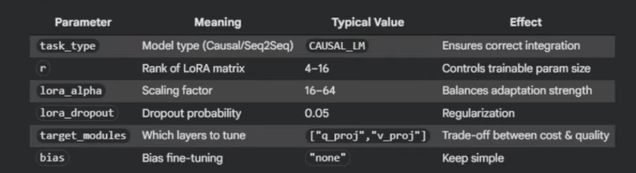

In [97]:

lora_config = LoraConfig(
    task_type = TaskType.CAUSAL_LM,
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none"
)

In [98]:
model = get_peft_model(model,lora_config)


/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


In [99]:

training_args = TrainingArguments(
    output_dir="./llama-instruction",
    num_train_epochs=2,
    per_device_train_batch_size=2,
    save_steps=500,
    save_total_limit=2,
    logging_steps=50,
    learning_rate=2e-5,
    dataloader_pin_memory=False,
    fp16=True,
    report_to="none"
)

In [100]:
trainer = Trainer(
    model = q_lora_model,
    args = training_args,
    train_dataset = tokenized
)

In [101]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


Step,Training Loss
50,7.346431
100,5.806932
150,3.307617
200,1.853156
250,1.574252
300,1.411319
350,1.506910
400,1.328985


TrainOutput(global_step=412, training_loss=2.968349049392256, metrics={'train_runtime': 357.4578, 'train_samples_per_second': 2.305, 'train_steps_per_second': 1.153, 'total_flos': 2621541451825152.0, 'train_loss': 2.968349049392256, 'epoch': 2.0})

In [102]:
model_path = '/content/llama-instruction/checkpoint-500'

In [103]:
instruction_model = AutoModelForCausalLM.from_pretrained(model_path, device_map = 'auto')

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/88 [00:00<?, ?it/s]

In [104]:
prompt = "I feel anxiety evertime i go to sleep what should i do"

In [105]:
inputs= tokenizer(prompt, return_tensors = "pt").to("cuda")

In [106]:
outputs = trained_model.generate(
    **inputs,
    max_new_tokens = 100,
    temperature = 0.8,
    top_p = 0.9,
    do_sample = True,
    repetition_penalty = 1.1
)

Both `max_new_tokens` (=100) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


In [107]:

print("\n Model Output: \n")
print(tokenizer.decode(outputs[0], skip_special_tokens=True))


 Model Output: 

I feel anxiety evertime i go to sleep what should i do.
I've been struggling with sleeping disorders for a couple of months now and have been going back and forth with the doc who says its probably all in my head and to not worry about it, he also has a 10 year old son which is very disturbing. He tells me that it will pass but as long as i don't worry about it i won't get anything done.
So I guess if he doesn't think it is an issue and
